In [1]:
import pandas as pd

In [2]:
import os

os.listdir("../data")

[]

In [3]:
import os

os.listdir("../data")

['online_retail_II.xlsx']

In [5]:
import pandas as pd

df = pd.read_excel("../data/online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.shape

(525461, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [9]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [10]:
df["Country"].nunique()

40

In [11]:
df["Country"].value_counts().head(10)

Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Name: count, dtype: int64

In [12]:
df["Description"].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    3549
REGENCY CAKESTAND 3 TIER              2212
STRAWBERRY CERAMIC TRINKET BOX        1843
PACK OF 72 RETRO SPOT CAKE CASES      1466
ASSORTED COLOUR BIRD ORNAMENT         1457
60 TEATIME FAIRY CAKE CASES           1400
HOME BUILDING BLOCK WORD              1386
JUMBO BAG RED RETROSPOT               1310
LUNCH BAG RED SPOTTY                  1274
REX CASH+CARRY JUMBO SHOPPER          1232
Name: count, dtype: int64

In [13]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [14]:
df["TotalPrice"].head()

0     83.4
1     81.0
2     81.0
3    100.8
4     30.0
Name: TotalPrice, dtype: float64

In [15]:
df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: TotalPrice, dtype: float64

In [16]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
TotalPrice          0
dtype: int64

In [17]:
df.duplicated().sum()

6865

In [18]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,TotalPrice
count,525461.000000,525461,525461.000000,417534.000000,525461.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,18.154506
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,-53594.360000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,3.750000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,9.950000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,17.700000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,25111.090000
std,107.424110,NaN,146.126914,1680.811316,160.333083


In [19]:
df.describe(include="object")

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [20]:
df = df.drop_duplicates()

In [21]:
df = df[df["Quantity"] > 0]

In [22]:
df = df[df["Price"] > 0]

In [23]:
df = df.dropna(subset=["Customer ID"])

In [24]:
df.shape

(400916, 9)

In [25]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER    56814
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54610
BROCADE RING PURSE                    48166
PACK OF 72 RETRO SPOT CAKE CASES      45129
ASSORTED COLOUR BIRD ORNAMENT         44431
60 TEATIME FAIRY CAKE CASES           35656
PACK OF 60 PINK PAISLEY CAKE CASES    30871
JUMBO BAG RED RETROSPOT               29519
SMALL POPCORN HOLDER                  25703
BLACK AND WHITE PAISLEY FLOWER MUG    25685
Name: Quantity, dtype: int64

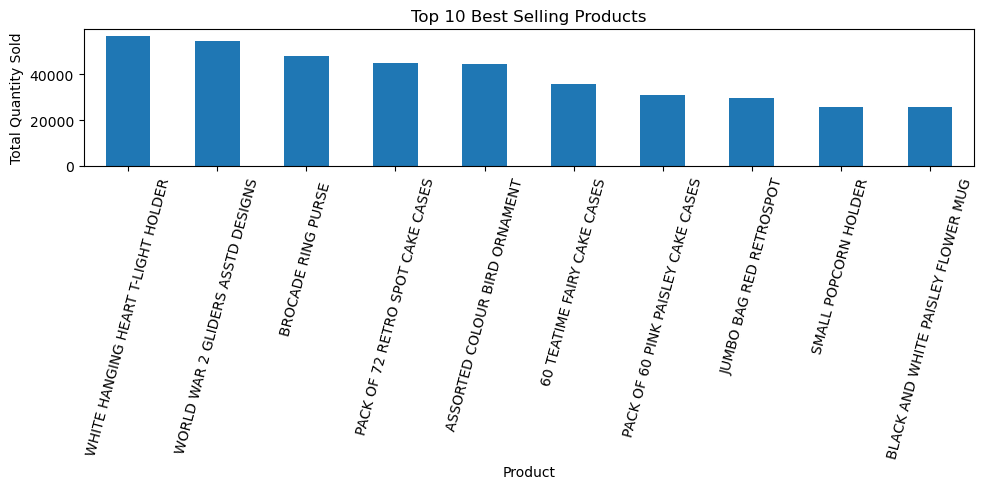

In [26]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

In [29]:
plt.savefig("../images/top_products.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [27]:
top_countries = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_countries

Country
United Kingdom    7381644.433
EIRE               356041.860
Netherlands        268784.350
Germany            202025.391
France             146107.070
Sweden              53147.990
Denmark             50906.850
Spain               47568.650
Switzerland         43921.390
Australia           31446.800
Name: TotalPrice, dtype: float64

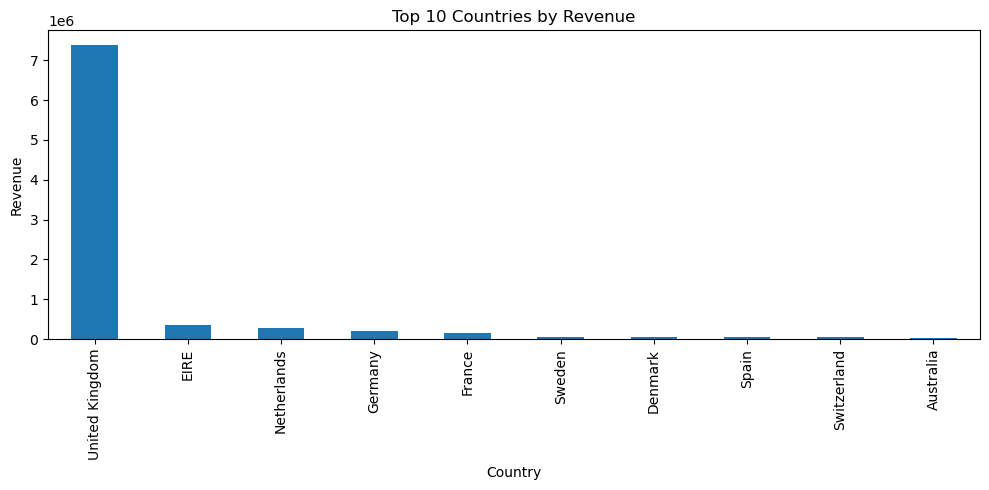

In [28]:
top_countries.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [30]:
plt.savefig("../images/top_countries.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [31]:
top_customers = (
    df.groupby("Customer ID")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196549.74
14911.0    152121.22
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: TotalPrice, dtype: float64

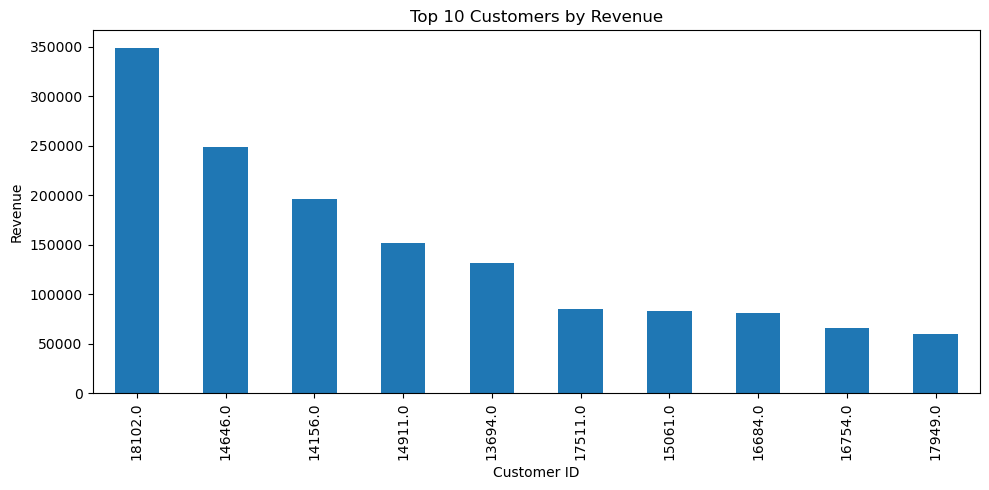

In [33]:
top_customers.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.tight_layout()
plt.savefig("../images/top_customers.png", dpi=300, bbox_inches="tight")
plt.show()